### panc analysis (batch effect correction)

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [28]:
import pandas as pd
from scipy.sparse import csr_matrix

# 创建示例数据
data = {
    "mod1_indx": [9, 0, 5, 1],
    "mod2_indx": [0, 5, 1, 9],
    "score": [0.861942, 0.803392, 0.885155, 0.827848]
}

# 转换为DataFrame
df = pd.DataFrame(data)

# 使用pivot函数转换数据，并填充缺失值为0
pivot_df = df.pivot(index='mod1_indx', columns='mod2_indx', values='score').fillna(0)

# 将DataFrame转换为稀疏矩阵
sparse_matrix = csr_matrix(pivot_df)

# 打印稀疏矩阵信息（为了验证）
print(sparse_matrix)

  (0, 2)	0.803392
  (1, 3)	0.827848
  (2, 1)	0.885155
  (3, 0)	0.861942


In [29]:
pivot_df

mod2_indx,0,1,5,9
mod1_indx,,,,
0,0.000000,0.000000,0.803392,0.000000
1,0.000000,0.000000,0.000000,0.827848
5,0.000000,0.885155,0.000000,0.000000
9,0.861942,0.000000,0.000000,0.000000


In [3]:
import pandas as pd
from scipy.sparse import csr_matrix

# 模拟数据输入
data = {
    "mod1_indx": [2, 0, 3, 4, 3],
    "mod2_indx": [5, 6, 7, 7, 9],
    "score": [0.861942, 0.803392, 0.885155, 0.827848, 0.879686]
}

# DataFrame转换
df = pd.DataFrame(data)

# 假设这些是从两个数据源中提取的索引
all_mod1_indx = pd.Index(range(0,10))
all_mod2_indx = pd.Index(range(0,10))  # 假设mod2_indx可以是0到14

# 使用pivot创建初始矩阵，并用0填充缺失值
pivot_df = df.pivot(index='mod1_indx', columns='mod2_indx', values='score').reindex(index=all_mod1_indx, columns=all_mod2_indx).fillna(0)

# 转换为CSR格式的稀疏矩阵
sparse_matrix = csr_matrix(pivot_df)

# 输出稀疏矩阵以验证
print(sparse_matrix)

  (0, 6)	0.803392
  (2, 5)	0.861942
  (3, 7)	0.885155
  (3, 9)	0.879686
  (4, 7)	0.827848


In [4]:
pivot_df

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.803392,0.000000,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.861942,0.000000,0.000000,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.885155,0.0,0.879686
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.827848,0.0,0.000000
5,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000
6,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000
7,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000
8,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000
9,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000


In [7]:
import pandas as pd

# 创建示例数据
data = {
    "mod1_indx": [6424, 9096, 9198, 4086, 3400, 9227, 7038, 1947, 1648, 2451],
    "mod2_indx": [0, 1, 5, 9, 11, 9994, 9995, 9996, 9997, 9998],
    "score": [0.861942, 0.803392, 0.885155, 0.827848, 0.879686, 0.516751, 0.524879, 0.573741, 0.549954, 0.757793]
}

# 转换为DataFrame
df = pd.DataFrame(data)

# 使用pivot函数转换数据
# 将mod2_indx作为新的列，mod1_indx作为行索引，score作为填充值
pivot_df = df.pivot(index='mod1_indx', columns='mod2_indx', values='score')

# 打印转换后的数据
print(pivot_df.iloc[1:4, 1:4])

mod2_indx   1   5   9
mod1_indx            
1947      NaN NaN NaN
2451      NaN NaN NaN
3400      NaN NaN NaN


In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)

gf.__version__

'0.1.2'

In [20]:
## 读取数据
# adata = sc.read_loom('../Garfield_test/data/panc8.loom',sparse=False)  #Load cell line dataset(-> count data). 
adata1 = sc.read_h5ad('/data2/human_embryo_data/jacob_hanna.h5ad') # jacob_hanna xiaoqun.h5ad mole.h5ad  tianqing.h5ad 
adata2 = sc.read_h5ad('/data2/human_embryo_data/xiaoqun.h5ad') # jacob_hanna xiaoqun.h5ad mole.h5ad  tianqing.h5ad 
adata3 = sc.read_h5ad('/data2/human_embryo_data/mole.h5ad') # jacob_hanna xiaoqun.h5ad mole.h5ad  tianqing.h5ad
adata4 = sc.read_h5ad('/data2/human_embryo_data/tianqing.h5ad') # jacob_hanna xiaoqun.h5ad mole.h5ad  tianqing.h5ad
adata5 = sc.read_h5ad('/data2/human_embryo_data/tyser.h5ad') # jacob_hanna xiaoqun.h5ad mole.h5ad  tianqing.h5ad

adata = adata1.concatenate(adata2, adata3, adata4, adata5)
# celltype = adata.obs['celltype']
adata

AnnData object with n_obs × n_vars = 37789 × 19274
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'anno', 'sub_anno', 'stage', 'Species', 'Categories', 'Embryo', 'Platform', 'sample', 'day', 'batch'
    var: 'features'

In [26]:
adata.layers['counts'] = adata.X.copy()

In [23]:
adata.obs['batch'].value_counts()

batch
1    12323
0    12190
2    11526
4     1195
3      555
Name: count, dtype: int64

In [27]:
# set workdir
workdir = 'result_garfield_scRNA_human_embryo' # result_garfield_multiome_10xpbmc3k_10k_Unpaired
gf.settings.set_workdir(workdir)

Saving results in: result_garfield_scRNA_human_embryo


In [28]:
gf.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [29]:
# make plots prettier
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

In [30]:
### modify parameter
user_config = dict(
    ## Input options
    data_dir=workdir,  # STR     Location of the dataset to be used.         Default is `data`.
    project_name='scRNA_adata_human_embryo',  # STR     Name of the dataset to be used.             Default is `name`.
    adata_list=adata,  # STR     adata object of single-cell dataset.         Default is `adata`.
    profile='RNA',
    data_type=None,  # Paired
    genome=None,
    sample_col='batch',  # STR     Column name of sample in adata.obs.       Default is `batch`.

    ## Preprocessing options
    rna_n_top_features=3000,
    atac_n_top_features=10000,  # INT     Number of top genes to be selected.       Default is 2000.
    metric='euclidean',  # STR     Metric for clustering.                   Default is `correlation`. euclidean

    ## Model options
    gnn_layer=2,
    hidden_dims=[128, 128],
    svd_q=5,  # default=5, type=int, help='rank'
    cluster_num=20,
    used_edge_weight=True,
    used_recon_exp=True,
    used_DSBN=True,
    used_mmd=True,
    batch_size=128,  # INT   batch size of model training
    num_neighbors=[5, 5],
    epochs=50,  # INT       Number of epochs.                        Default is 100.
    mmd_temperature=0.2,  ## mmd regu
    instance_temperature=1.0,
    cluster_temperature=0.5,
    monitor_only_val_losses=False,
    learning_rate=0.001
)
dict_config = gf.settings.set_gf_params(user_config)

In [2]:
import torch

def mcca_by_svd(datasets, n_components=10):
    """
    Multi-view CCA using SVD, simplified version.
    Assumes all datasets are torch tensors with matching number of samples.
    """
    # Center each dataset by subtracting the mean of its features
    mean_corrected_datasets = [d - d.mean(0) for d in datasets]
    concatenated_data = torch.cat(mean_corrected_datasets, dim=1)
    
    # Perform SVD on the concatenated data matrix
    U, S, V = torch.svd(concatenated_data)
    
    # Extract the top components from the U matrix since it aligns with the data rows
    top_components = U[:, :n_components]
    
    # Project each dataset onto the top components
    projections = [d @ top_components for d in mean_corrected_datasets]
    return projections

# Example datasets
data1 = torch.randn(100, 50)
data2 = torch.randn(100, 50)
data3 = torch.randn(100, 50)

# Perform MCCA
mcca_results = mcca_by_svd([data1, data2, data3], n_components=10)

# mcca_results now contains projections of data1, data2, data3 into a common space
mcca_results

RuntimeError: mat1 and mat2 shapes cannot be multiplied (100x50 and 100x10)

In [31]:
## start training
from Garfield.model import GarfieldTrainer
trainer = GarfieldTrainer(dict_config)
trainer.fit()


Preparing dataset...



Processing...


Data preprocessing and graph construction finished
Data files exist, loading...


Done!


Finished loading.

Model training.

 |--------------------| 2.0%  - epoch_total_loss: 909.4733276367 - epoch_vgae_loss: 0.1555346679 - epoch_instance_loss: 8.6746239662 - epoch_cluster_loss: 3.6871678829 - epoch_recon_loss: 887.6580810547 - epoch_regu_loss: 8.0728607178 - epoch_mmd_loss: 6.1250414848 - val_total_loss: 885.0874023438 - val_vgae_loss: 0.0687631816 - val_instance_loss: 8.5349836349 - val_cluster_loss: 3.6610829830 - val_recon_loss: 863.5156250000 - val_regu_loss: 8.0604667664 - val_mmd_loss: 6.2322444916 - test_roc_auc: 0.4807256236 - test_precision: 0.554491139037131

ValueError: Input contains NaN.

In [ ]:
import scanpy as sc
adata_final = trainer.get_latent_representation()
adata_final

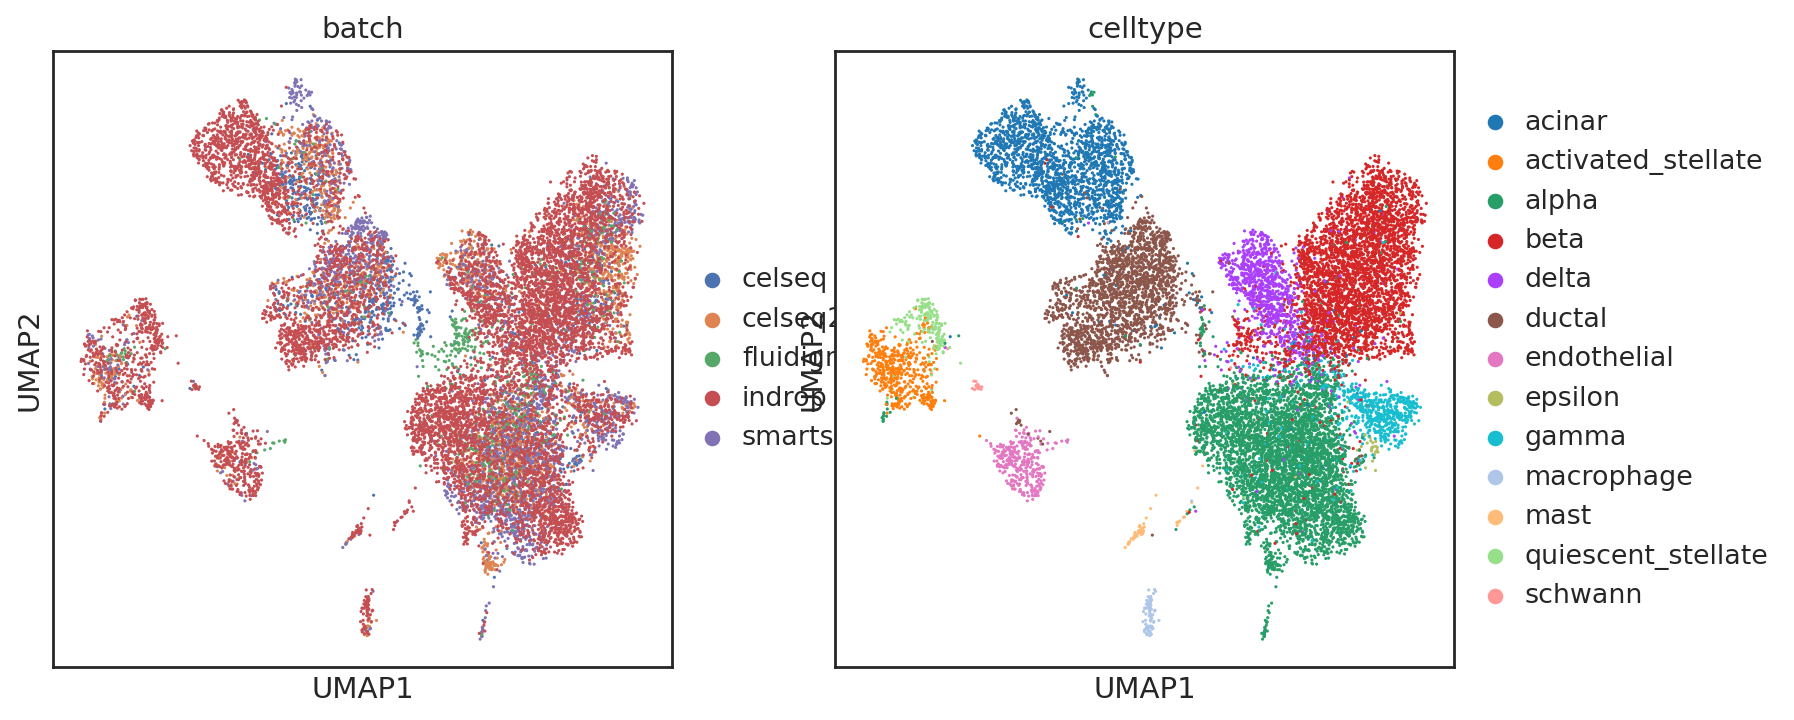

In [13]:
sc.tl.umap(adata_final)

# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['batch', 'anno'], wspace=0.35, edges=False)

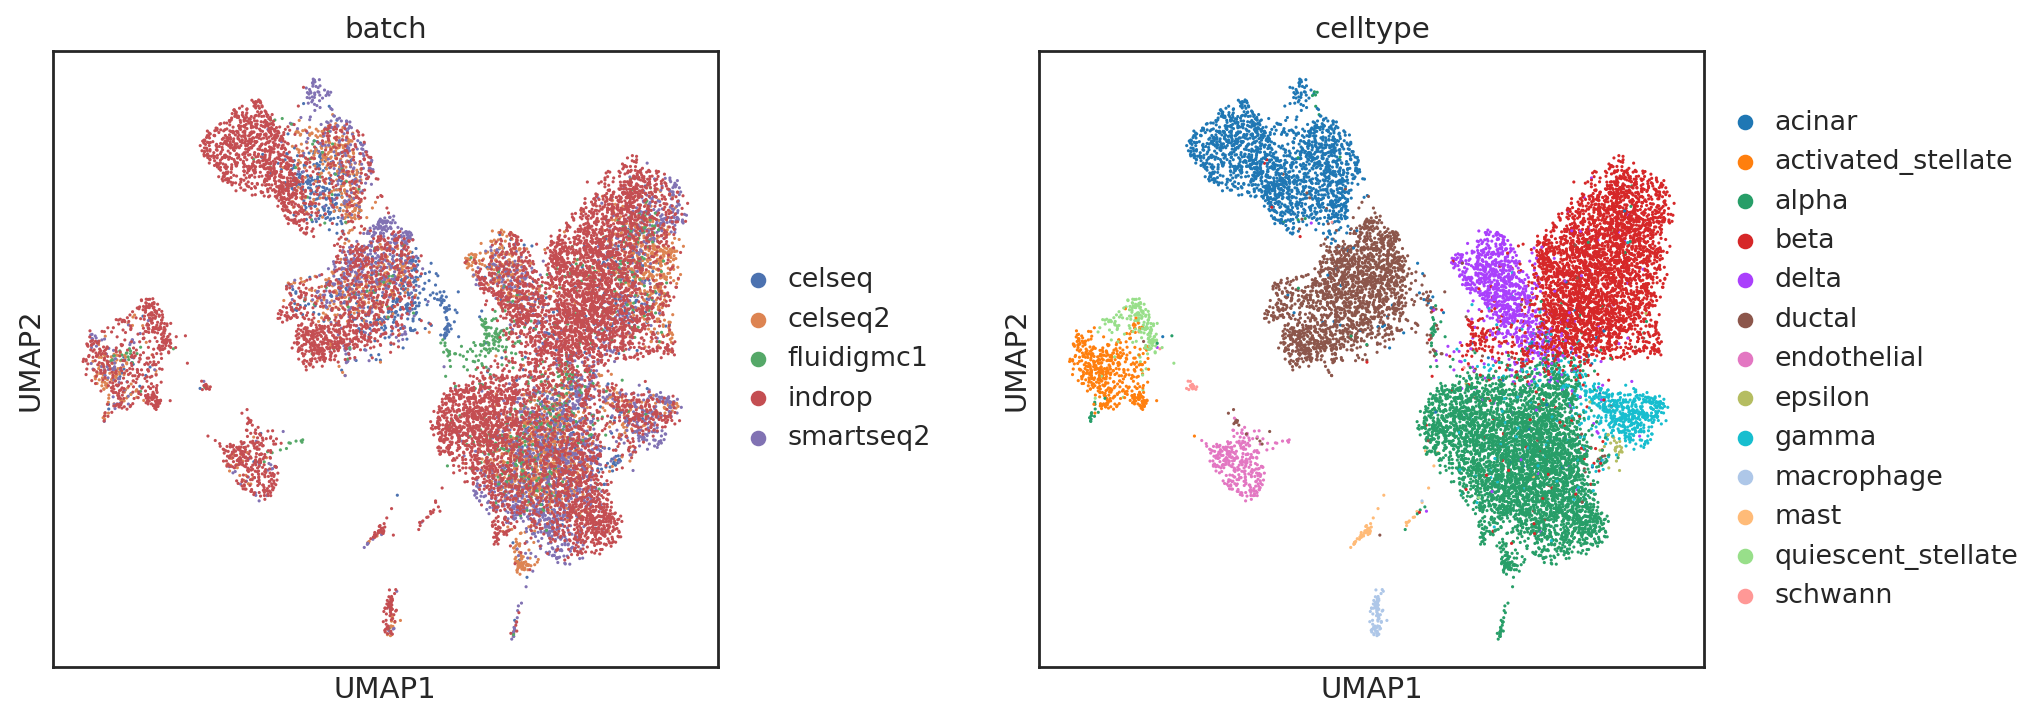

In [14]:
#设置全域sc的画图背景为白色，dpi=50分辨率
# sc.settings.set_figure_params(dpi=80, facecolor="black")

sc.pl.umap(adata_final, color=['batch', 'celltype'], wspace=0.35, edges=False, save='_panc_umap.pdf')

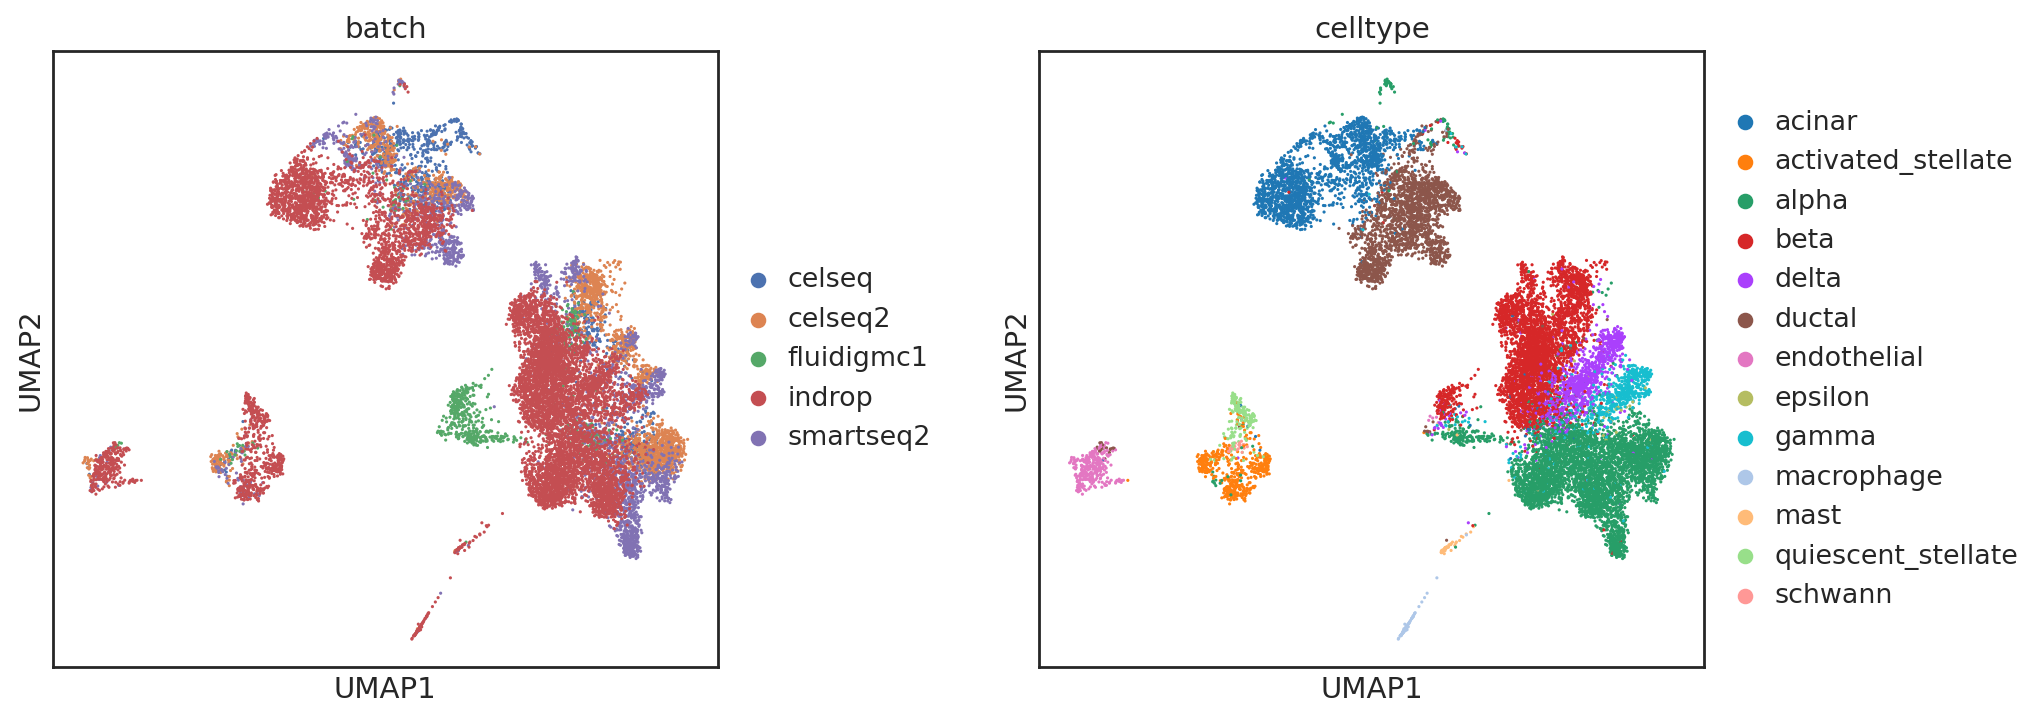

In [15]:
### scanorama 对照
sc.pp.neighbors(adata_final, use_rep='X_scanorama')
sc.tl.umap(adata_final)

# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['batch', 'celltype'], wspace=0.35, edges=False, save='_panc_umap_scanorama.pdf')